###  Machine Learning Pipeline

 - Load Libraries

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


- Load Dataset

(545, 4) (545,)
area         0
bedrooms     0
bathrooms    0
parking      0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       545 non-null    int64
 1   bedrooms   545 non-null    int64
 2   bathrooms  545 non-null    int64
 3   parking    545 non-null    int64
dtypes: int64(4)
memory usage: 17.2 KB
None
               area    bedrooms   bathrooms     parking
count    545.000000  545.000000  545.000000  545.000000
mean    5150.541284    2.965138    1.286239    0.693578
std     2170.141023    0.738064    0.502470    0.861586
min     1650.000000    1.000000    1.000000    0.000000
25%     3600.000000    2.000000    1.000000    0.000000
50%     4600.000000    3.000000    1.000000    0.000000
75%     6360.000000    3.000000    2.000000    1.000000
max    16200.000000    6.000000    4.000000    3.000000
count    5.450000e+02
mean   

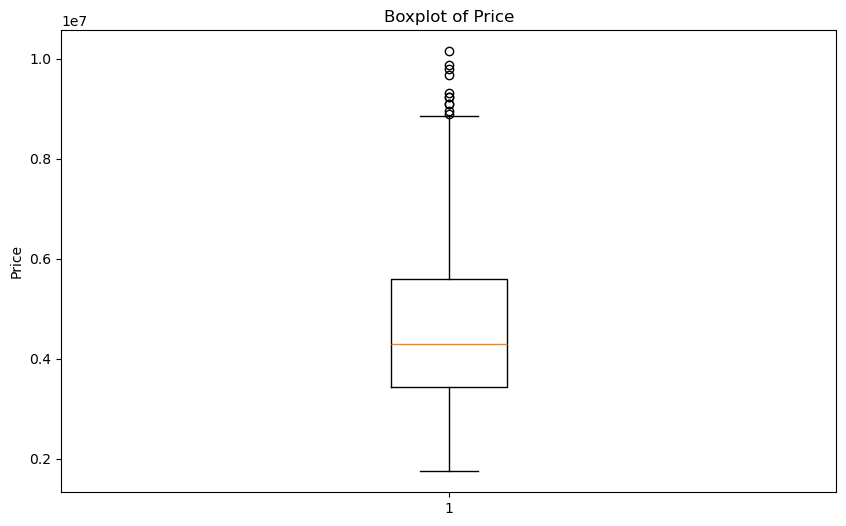

In [119]:
df = pd.read_csv("../dataset/Housing.csv") 

X = df[["area", "bedrooms", "bathrooms","parking"]]
y = df["price"]

# check the shape of the data
print(X.shape, y.shape)
# try to display the first 20 rows of the data
X.head(20)
# check for missing values in the data
print(X.isnull().sum())
# check for missing values in the target variable
print(y.isnull().sum())
# info
print(X.info())
# describe the data
print(X.describe())

# target values description
print(y.describe())



# Columns jinke outliers remove karne hain
cols = ["area", "bedrooms", "bathrooms", "parking", "price"]

# Q1 and Q3
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Lower and upper limits
lower = Q1 - 2 * IQR
upper = Q3 + 2 * IQR

# Outlier rows remove
df_clean = df[
    ~((df[cols] < lower) | (df[cols] > upper)).any(axis=1)
].copy()

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

X = df_clean[["area", "bedrooms", "bathrooms", "parking"]]
y = df_clean["price"]



# target variable distribution
plt.figure(figsize=(10, 6))
plt.boxplot(y)
plt.title("Boxplot of Price")
plt.ylabel("Price")
plt.show()



## Boxplot for price

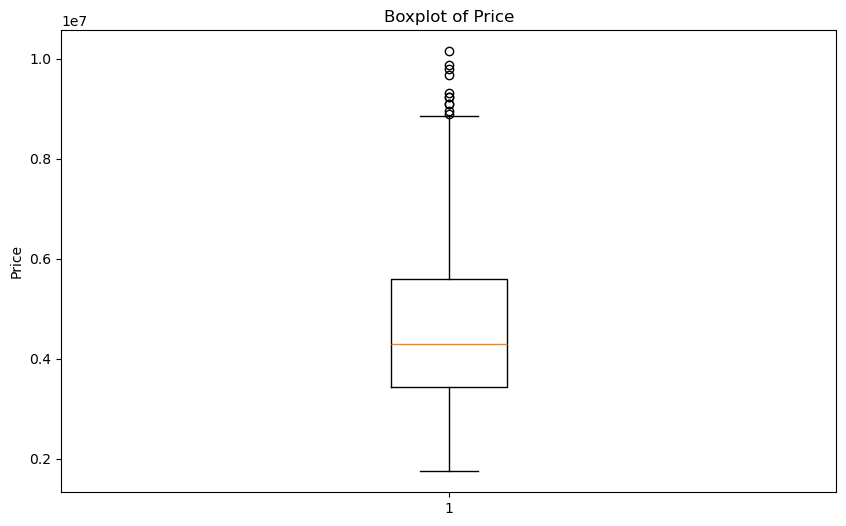

In [120]:
figure =  figure = plt.figure(figsize=(10, 6))

plt.boxplot(y)
plt.title("Boxplot of Price")   
plt.ylabel("Price")
plt.show()




## Boxplot for ["area", "bedrooms", "bathrooms","parking"]



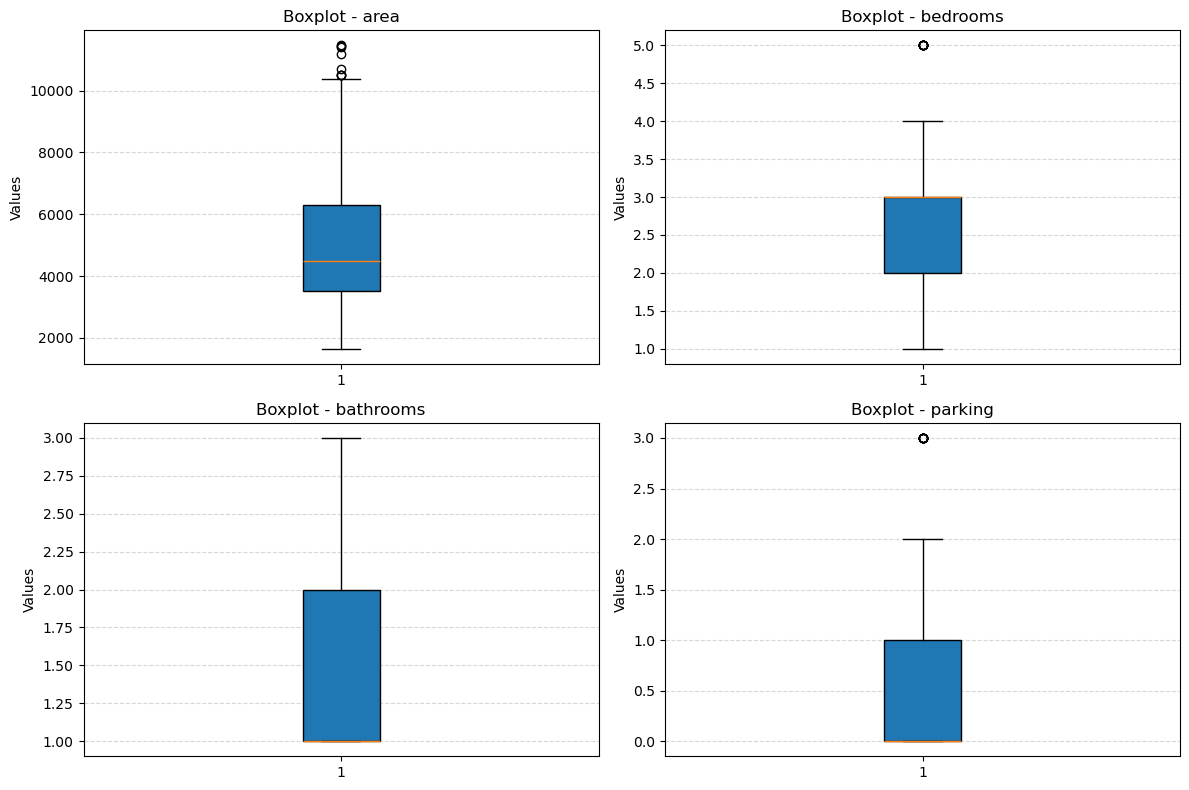

In [121]:

import matplotlib.pyplot as plt

columns = ["area", "bedrooms", "bathrooms", "parking"]

cals = [
    X["area"].dropna(),
    X["bedrooms"].dropna(),
    X["bathrooms"].dropna(),
    X["parking"].dropna()
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, data in zip(axes.flat, columns, cals):
    ax.boxplot(data, patch_artist=True)
    ax.set_title(f"Boxplot - {col}")
    ax.set_ylabel("Values")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

- Train-Test Split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

- Create pipeline

In [123]:
# pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler()),
#     ("regressor", LinearRegression())
# ])

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("regressor", LinearRegression())
])

- Training

In [124]:

pipeline.fit(
    X_train,
    y_train
)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


- Prediction

In [125]:
y_pred = pipeline.predict(
    X_test
)

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Predicted prices: {y_pred[:5]}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", round(rmse, 2))

Mean Squared Error: 1874626156830.22
R-squared Score: 0.52
Mean Absolute Error: 1048844.00
Predicted prices: [5098596.77895202 4294954.00031175 6311027.37780067 3632662.35942787
 3864319.9490966 ]
RMSE: 1369169.88
